<a href="https://colab.research.google.com/github/m22aie202/FM_GenAI/blob/main/m22aie202_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets torchtext

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import re
import numpy as np
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
#first 50,000 sentence pairs
dataset = load_dataset("OscarNav/spa-eng", split="train[:50000]")

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return text

In [ ]:
print(dataset[0])

{'eng': 'When the curtain went up, the stage was dark.', 'spa': 'Al levantarse el telón, la escena estaba oscura.'}


In [ ]:
pairs = []

for item in dataset:
    en = clean_text(item["eng"])
    es = "[start] " + clean_text(item["spa"]) + " [end]"
    pairs.append((en, es))

In [ ]:
#15,000 words and a maximum sequence length of 20 tokens
max_vocab = 15000
max_len = 20

counter = Counter()

for en, es in pairs:
    counter.update(en.split())
    counter.update(es.split())

vocab = ["<pad>", "<unk>"] + [word for word, _ in counter.most_common(max_vocab-2)]
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}
vocab_size = len(vocab)

In [ ]:
def encode(sentence):
    tokens = sentence.split()[:max_len]
    ids = [word2idx.get(t, word2idx["<unk>"]) for t in tokens]
    ids += [word2idx["<pad>"]] * (max_len - len(ids))
    return ids

In [ ]:
data = [(encode(en), encode(es)) for en, es in pairs]

train_data = data[:45000]
val_data   = data[45000:50000]

In [ ]:
def create_loader(dataset, batch_size=64):
    src = torch.tensor([x[0] for x in dataset])
    tgt = torch.tensor([x[1] for x in dataset])
    return torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(src, tgt),
        batch_size=batch_size,
        shuffle=True
    )

train_loader = create_loader(train_data)
val_loader   = create_loader(val_data)

In [ ]:
class ScaledDotProductAttention(nn.Module):
    def forward(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2,-1)) / math.sqrt(Q.size(-1))
        if mask is not None:
            scores = scores + mask
        attn = F.softmax(scores, dim=-1)
        return torch.matmul(attn, V)

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=256, num_heads=4, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.fc  = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        b, seq, d = x.size()
        x = x.view(b, seq, self.num_heads, self.d_k)
        return x.transpose(1,2)

    def forward(self, Q_input, K_input, V_input, mask=None):
        Q = self.split_heads(self.W_q(Q_input))
        K = self.split_heads(self.W_k(K_input))
        V = self.split_heads(self.W_v(V_input))

        attn = ScaledDotProductAttention()(Q,K,V,mask)

        attn = attn.transpose(1,2).contiguous()
        attn = attn.view(attn.size(0), -1, self.num_heads*self.d_k)

        return self.fc(self.dropout(attn))

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.self_attn = MultiHeadAttention()
        self.norm1 = nn.LayerNorm(256)
        self.norm2 = nn.LayerNorm(256)
        self.ff = nn.Sequential(
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512,256)
        )
        self.dropout = nn.Dropout(0.1)

    def forward(self,x):
        x = self.norm1(x + self.dropout(self.self_attn(x,x,x)))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.self_attn  = MultiHeadAttention()
        self.cross_attn = MultiHeadAttention()

        self.norm1 = nn.LayerNorm(256)
        self.norm2 = nn.LayerNorm(256)
        self.norm3 = nn.LayerNorm(256)

        self.ff = nn.Sequential(
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512,256)
        )
        self.dropout = nn.Dropout(0.1)

    def forward(self,x,enc_out,mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x,x,x,mask)))
        x = self.norm2(x + self.dropout(self.cross_attn(x,enc_out,enc_out)))
        x = self.norm3(x + self.dropout(self.ff(x)))
        return x

In [ ]:
class Transformer(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.src_embed = nn.Embedding(vocab_size,256)
        self.tgt_embed = nn.Embedding(vocab_size,256)

        self.pos_enc = PositionalEncoding()

        self.encoder_layers = nn.ModuleList([EncoderLayer() for _ in range(2)])
        self.decoder_layers = nn.ModuleList([DecoderLayer() for _ in range(2)])

        self.fc = nn.Linear(256,vocab_size)

        # Weight tying (improves quality)
        self.fc.weight = self.tgt_embed.weight

    def generate_mask(self, size):
        mask = torch.triu(torch.ones(size, size), diagonal=1)
        mask = mask.masked_fill(mask==1, float('-inf'))
        return mask

    def forward(self,src,tgt):
        src = self.pos_enc(self.src_embed(src))
        tgt = self.pos_enc(self.tgt_embed(tgt))

        for layer in self.encoder_layers:
            src = layer(src)

        mask = self.generate_mask(tgt.size(1)).to(tgt.device)
        mask = mask.unsqueeze(0).unsqueeze(0)

        for layer in self.decoder_layers:
            tgt = layer(tgt, src, mask)

        return self.fc(tgt)

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model=256, max_len=20):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Transformer(vocab_size).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

criterion = nn.CrossEntropyLoss(
    ignore_index=word2idx["<pad>"],
    label_smoothing=0.1
)

train_losses = []
val_losses = []

for epoch in range(20):
    model.train()
    total_loss = 0

    for src,tgt in train_loader:
        src,tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()

        output = model(src, tgt[:,:-1])
        loss = criterion(
            output.reshape(-1,vocab_size),
            tgt[:,1:].reshape(-1)
        )

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_losses.append(total_loss/len(train_loader))

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for src,tgt in val_loader:
            src,tgt = src.to(device), tgt.to(device)
            output = model(src,tgt[:,:-1])
            loss = criterion(
                output.reshape(-1,vocab_size),
                tgt[:,1:].reshape(-1)
            )
            val_loss += loss.item()

    val_losses.append(val_loss/len(val_loader))

    print(f"Epoch {epoch+1}: Train {train_losses[-1]:.4f}, Val {val_losses[-1]:.4f}")

Epoch 1: Train 16.3527, Val 8.2390
Epoch 2: Train 7.7742, Val 6.0284
Epoch 3: Train 6.1294, Val 5.1166
Epoch 4: Train 5.2655, Val 4.6973
Epoch 5: Train 4.7248, Val 4.3222
Epoch 6: Train 4.3530, Val 4.1476
Epoch 7: Train 4.1033, Val 3.9931
Epoch 8: Train 3.9232, Val 3.8792
Epoch 9: Train 3.7777, Val 3.7914
Epoch 10: Train 3.6501, Val 3.7252
Epoch 11: Train 3.5367, Val 3.6564
Epoch 12: Train 3.4328, Val 3.6191
Epoch 13: Train 3.3361, Val 3.5740
Epoch 14: Train 3.2485, Val 3.5316
Epoch 15: Train 3.1680, Val 3.4937
Epoch 16: Train 3.0858, Val 3.4677
Epoch 17: Train 3.0131, Val 3.3869
Epoch 18: Train 2.9488, Val 3.4329
Epoch 19: Train 2.8837, Val 3.3866
Epoch 20: Train 2.8285, Val 3.3457


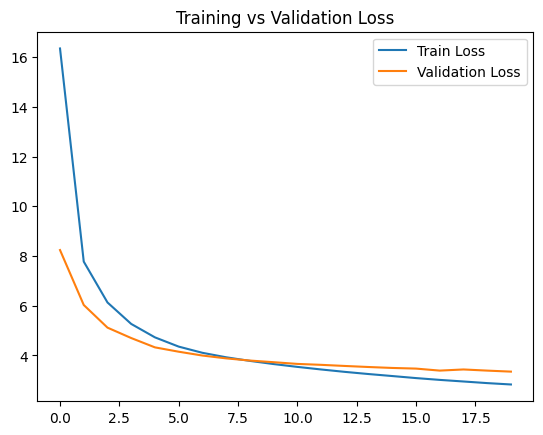

In [ ]:
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [ ]:
def greedy_decode(model, src_sentence):
    model.eval()
    src = torch.tensor([encode(src_sentence)]).to(device)
    generated = [word2idx["[start]"]]

    for _ in range(20):
        tgt = torch.tensor([generated]).to(device)
        output = model(src,tgt)
        next_token = torch.argmax(
            F.log_softmax(output[:,-1,:],dim=-1),
            dim=-1
        ).item()

        generated.append(next_token)
        if idx2word[next_token] == "[end]":
            break

    return " ".join([idx2word[i] for i in generated])

In [ ]:
for i in range(5):
    src = pairs[45000+i][0]
    tgt = pairs[45000+i][1]
    pred = greedy_decode(model, src)

    print("Source English:", src)
    print("Target Spanish:", tgt)
    print("Model Prediction:", pred)
    print("-"*50)

Source English: tom was a judge in an art contest
Target Spanish: [start] tom fue juez en un concurso de arte [end]
Model Prediction: [start] tom fue un juez en un arte [end]
--------------------------------------------------
Source English: its my umbrella
Target Spanish: [start] es mi paraguas [end]
Model Prediction: [start] es mi paraguas [end]
--------------------------------------------------
Source English: you may choose whichever you want
Target Spanish: [start] tú puedes elegir la que quieras [end]
Model Prediction: [start] puede elegir que quieras [end]
--------------------------------------------------
Source English: i cant eat the apple
Target Spanish: [start] no puedo comerme la manzana [end]
Model Prediction: [start] no puedo comer el manzana [end]
--------------------------------------------------
Source English: tom i bet youd be a good teacher
Target Spanish: [start] tom apuesto a que eres un buen profesor [end]
Model Prediction: [start] tom apuesto a que te <unk> un 

Self-attention and cross-attention serve complementary roles in neural machine translation. In the encoder, self-attention allows every English token to attend to all other tokens in the same sentence. This enables the model to build contextualized representations where each word captures semantic relationships across the entire sequence. For e.g. ambiguous words are disambiguated using surrounding context.

Similarly, decoder self-attention ensures that each generated Spanish token depends on previously generated tokens. This preserves grammatical structure and maintains fluency by modeling target-language dependencies.

However, self-attention alone is insufficient for translation because it does not connect the source and target languages. Cross-attention enables this connection. In cross-attention, the decoder’s hidden states form queries, while the encoder outputs provide keys and values. This allows every generated Spanish word to attend to all positions in the English sentence. As a result, the model dynamically aligns source and target tokens during generation.

Without cross-attention, the decoder would behave like an independent language model and produce fluent but unrelated text. Therefore, self-attention ensures contextual coherence within each language, while cross-attention provides semantic grounding across languages. Together, they enable effective translation.